# Understanding the Bias–Variance Trade-off using K-Nearest Neighbour

This notebook demonstrates how the value of **K** in the K-Nearest Neighbour (KNN) algorithm affects model complexity, bias, variance and generalisation performance.

The experiment uses a classification dataset and compares training and validation accuracy for different values of K.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Step 1: Load the dataset

A simple classification dataset is needed to study how model complexity changes with different K values.

In [2]:
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Classes:", np.unique(y))

Feature matrix shape: (500, 2)
Target vector shape: (500,)
Classes: [0 1]


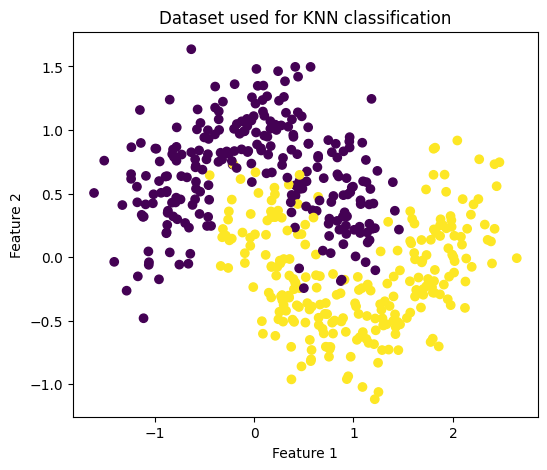

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset used for KNN classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Step 2: Split the data into training and validation sets

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 350
Validation samples: 150


## Step 3: Standardise the features

KNN is a distance-based algorithm, so feature scaling is important.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Step 4: Train KNN models with different K values

In [6]:
k_values = list(range(1, 31))
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_train_pred = knn.predict(X_train_scaled)
    y_val_pred = knn.predict(X_val_scaled)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

In [7]:
best_k = k_values[np.argmax(val_accuracies)]
best_val_acc = max(val_accuracies)

print("Best K:", best_k)
print("Best Validation Accuracy:", round(best_val_acc, 4))

Best K: 15
Best Validation Accuracy: 0.96


## Step 5: Plot training and validation accuracy

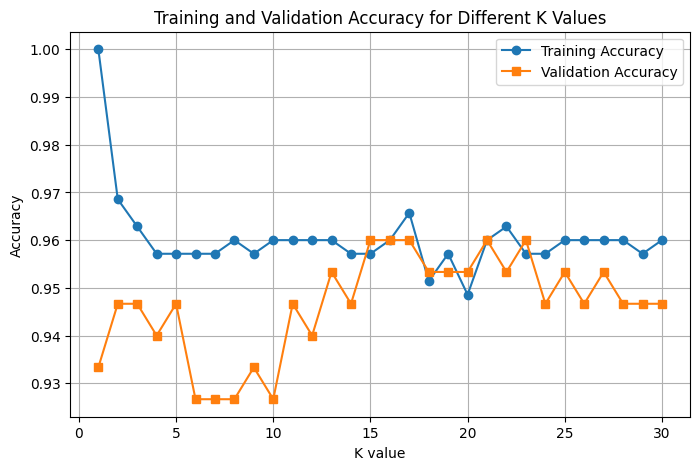

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(k_values, val_accuracies, marker="s", label="Validation Accuracy")
plt.title("Training and Validation Accuracy for Different K Values")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("knn_bias_variance_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 6: Interpret the result

Small K values usually produce high training accuracy but unstable validation accuracy, which suggests high variance and possible overfitting.

Large K values produce smoother decision boundaries and lower variance, but they may become too simple and underfit the data, which increases bias.

The best validation accuracy is usually achieved at an intermediate value of K, where bias and variance are balanced.

## Step 7: Visualise decision boundaries for selected K values

In [9]:
def plot_decision_boundary(X_data, y_data, k, ax):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = model.predict(grid_scaled).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, edgecolor="k", s=20)
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

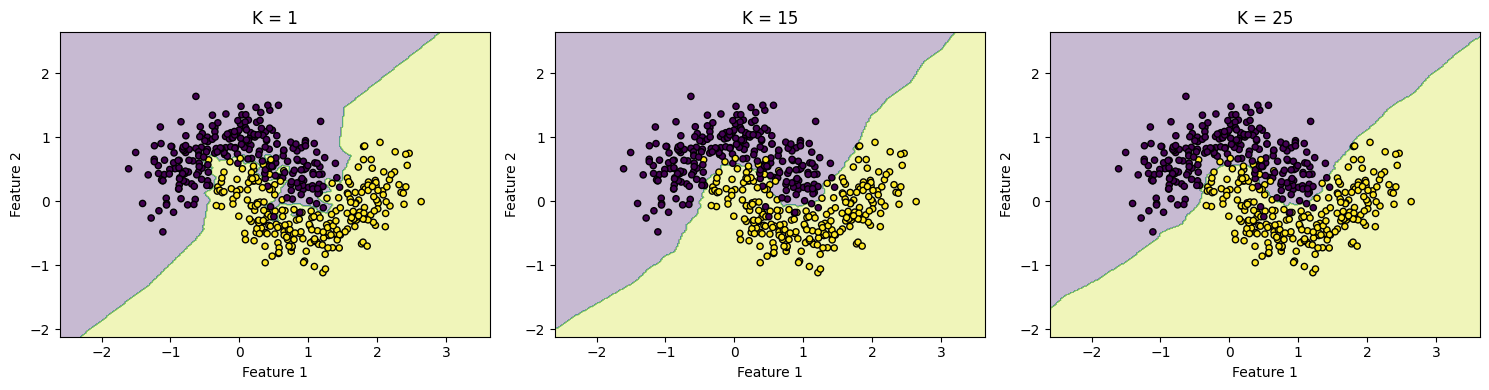

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, [1, best_k, 25]):
    plot_decision_boundary(X, y, k, ax)

plt.tight_layout()
plt.savefig("knn_decision_boundaries.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 8: Final conclusion

This experiment shows the bias–variance trade-off clearly. Very small K values create flexible models with high variance, while large K values create simpler models with higher bias. A moderate K value usually gives the best validation performance because it balances both effects.

# Bias–Variance Trade-off using K-Nearest Neighbour

## Repository Link  
GitHub Repository: https://github.com/Vivek-6-afk/bias-variance-knn

This notebook contains the full experimental implementation used in the tutorial report.  
All figures and results presented in the report can be reproduced by running the cells in order.

## Step 9: Create a results table

The table below compares training and validation accuracy for each value of K.

In [11]:
import pandas as pd

results_df = pd.DataFrame({
    "K": k_values,
    "Training Accuracy": train_accuracies,
    "Validation Accuracy": val_accuracies
})

results_df.head(10)

,K,Training Accuracy,Validation Accuracy
0,1,1.000000,0.933333
1,2,0.968571,0.946667
2,3,0.962857,0.946667
3,4,0.957143,0.940000
4,5,0.957143,0.946667
5,6,0.957143,0.926667
6,7,0.957143,0.926667
7,8,0.960000,0.926667
8,9,0.957143,0.933333
9,10,0.960000,0.926667


In [12]:
results_df

,K,Training Accuracy,Validation Accuracy
0,1,1.000000,0.933333
1,2,0.968571,0.946667
2,3,0.962857,0.946667
3,4,0.957143,0.940000
4,5,0.957143,0.946667
5,6,0.957143,0.926667
6,7,0.957143,0.926667
7,8,0.960000,0.926667
8,9,0.957143,0.933333
9,10,0.960000,0.926667


## Step 10: Highlight the best model

The best model is selected using validation accuracy because the aim is to find a value of K that generalises well to unseen data.

In [13]:
best_row = results_df.loc[results_df["Validation Accuracy"].idxmax()]
best_row

,14
K,15.000000
Training Accuracy,0.957143
Validation Accuracy,0.960000


In [14]:
print("Best K value:", int(best_row["K"]))
print("Training Accuracy at best K:", round(best_row["Training Accuracy"], 4))
print("Validation Accuracy at best K:", round(best_row["Validation Accuracy"], 4))

Best K value: 15
Training Accuracy at best K: 0.9571
Validation Accuracy at best K: 0.96


## Step 11: Save the results table

This step is optional, but it can help if you want to include the table in your GitHub repository.

In [15]:
results_df.to_csv("knn_bias_variance_results.csv", index=False)
print("Results table saved as knn_bias_variance_results.csv")

Results table saved as knn_bias_variance_results.csv


## Discussion

The experiment shows that KNN provides a clear example of the bias–variance trade-off. When K is too small, the classifier becomes highly flexible and closely follows individual training samples. This reduces bias but increases variance, which can harm validation performance. When K is too large, the classifier becomes too smooth and may ignore useful local patterns, which increases bias. The best validation result appears at an intermediate K value, showing that balanced model complexity is important for generalisation.

## Accessibility Note

This notebook uses clear headings, readable plots and step-by-step explanations. Saved figures can be reused in the PDF tutorial with descriptive captions to support accessibility.